In [41]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [42]:
(train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

train_images = train_images.astype("float32")
train_images = (train_images - 127.5) / 127.5
train_images = np.expand_dims(train_images, axis=-1)

BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [43]:
def make_generator():
    model = tf.keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(100,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(28*28, activation='tanh'),
        layers.Reshape((28,28,1))
    ])
    return model

generator = make_generator()


In [ ]:
def make_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1)
    ])
    return model

discriminator = make_discriminator()


In [45]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

gen_optimizer = tf.keras.optimizers.Adam(2e-4)
disc_optimizer = tf.keras.optimizers.Adam(5e-5)


In [46]:
noise_dim = 100

@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated, training=True)

        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return g_loss, d_loss


In [47]:
EPOCHS = 80

gen_losses = []
disc_losses = []

for epoch in range(EPOCHS):

    for image_batch in dataset:
        g_loss, d_loss = train_step(image_batch)

    gen_losses.append(g_loss.numpy())
    disc_losses.append(d_loss.numpy())

    print(f"Epoch {epoch+1}: Generator Loss={g_loss:.4f}, Discriminator Loss={d_loss:.4f}")


Epoch 1: Generator Loss=2.3730, Discriminator Loss=0.1879
Epoch 2: Generator Loss=1.2655, Discriminator Loss=0.4922
Epoch 3: Generator Loss=1.7166, Discriminator Loss=0.3636
Epoch 4: Generator Loss=1.4468, Discriminator Loss=0.5391
Epoch 5: Generator Loss=1.6074, Discriminator Loss=0.5606
Epoch 6: Generator Loss=1.6624, Discriminator Loss=0.4421
Epoch 7: Generator Loss=1.7453, Discriminator Loss=0.5433
Epoch 8: Generator Loss=1.7468, Discriminator Loss=0.5210
Epoch 9: Generator Loss=1.8479, Discriminator Loss=0.6092
Epoch 10: Generator Loss=2.0207, Discriminator Loss=0.6061
Epoch 11: Generator Loss=1.7206, Discriminator Loss=0.5476
Epoch 12: Generator Loss=1.4491, Discriminator Loss=0.5935
Epoch 13: Generator Loss=1.7651, Discriminator Loss=0.7013
Epoch 14: Generator Loss=1.7248, Discriminator Loss=0.6405
Epoch 15: Generator Loss=1.4619, Discriminator Loss=0.7553
Epoch 16: Generator Loss=2.1164, Discriminator Loss=0.7572
Epoch 17: Generator Loss=1.5681, Discriminator Loss=0.6916
Epoch 

2026-02-09 14:57:47.899867: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 56: Generator Loss=1.2277, Discriminator Loss=1.0185
Epoch 57: Generator Loss=1.2543, Discriminator Loss=0.9398
Epoch 58: Generator Loss=1.0869, Discriminator Loss=1.0855
Epoch 59: Generator Loss=1.0652, Discriminator Loss=1.2113
Epoch 60: Generator Loss=1.2647, Discriminator Loss=0.9270
Epoch 61: Generator Loss=1.0855, Discriminator Loss=1.2210
Epoch 62: Generator Loss=1.1323, Discriminator Loss=1.1303
Epoch 63: Generator Loss=1.0701, Discriminator Loss=1.1317
Epoch 64: Generator Loss=1.1260, Discriminator Loss=1.0949
Epoch 65: Generator Loss=1.0622, Discriminator Loss=1.0206
Epoch 66: Generator Loss=1.1145, Discriminator Loss=0.9134
Epoch 67: Generator Loss=1.0291, Discriminator Loss=1.1113
Epoch 68: Generator Loss=1.0739, Discriminator Loss=1.0590
Epoch 69: Generator Loss=1.1324, Discriminator Loss=0.9486
Epoch 70: Generator Loss=0.9938, Discriminator Loss=1.1603
Epoch 71: Generator Loss=1.1234, Discriminator Loss=1.0430
Epoch 72: Generator Loss=1.0096, Discriminator Loss=1.33

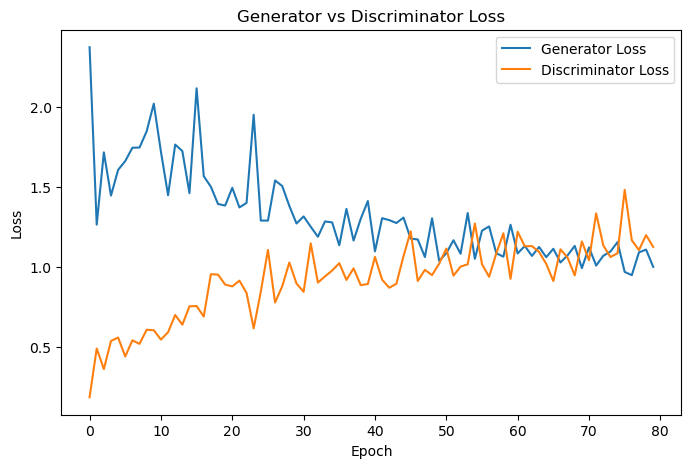

In [48]:
plt.figure(figsize=(8,5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator vs Discriminator Loss")
plt.legend()
plt.show()


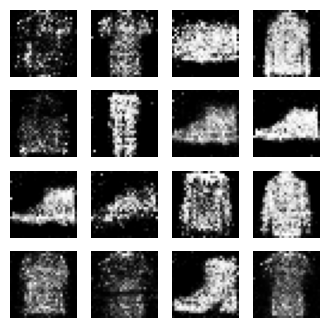

In [49]:
noise = tf.random.normal([16, noise_dim])
generated_images = generator(noise, training=False)

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i,:,:,0], cmap='gray')
    plt.axis('off')
plt.show()


In [50]:
## Analysis

# Initially, the discriminator loss is low while generator loss is high, since the discriminator easily identifies fake images.

# As training progresses, generator loss decreases while discriminator loss increases or oscillates. 

# This shows the generator is improving and producing more realistic digits.

# Eventually, both losses fluctuate around similar values, indicating adversarial balance. 

# This oscillation is expected in GANs because both networks continuously compete.

# Visual inspection confirms that generated images gradually resemble real MNIST digits.

# This demonstrates successful adversarial learning and effective modeling of the data distribution.
